# Train YOLO26n-cls disease classifier — Strawberry Vision Pi (Phase 3)

Trains the disease classifier on per-fruit/leaf crops cut from two source datasets:
- **Kaggle Afzaal** (Usman Afzaal) — LabelMe polygons, 7 disease classes (~3,200 source images, ~5–8k crops after polygon extraction).
- **Roboflow research-proj/strawberry-diseases-detection** v1 — YOLO bbox, contributes the `healthy` class only via its native `Healthy Fruit` annotations.

8-way classifier: `angular_leafspot`, `anthracnose_fruit_rot`, `blossom_blight`, `gray_mold`, `healthy`, `leaf_spot`, `powdery_mildew_fruit`, `powdery_mildew_leaf`.

Two runs:
- **yolo26n-cls** — production model that ships to the Pi (cls runs on tight crops at 224×224, plenty fast).
- **yolo26s-cls** — ablation upper-bound. Same data, same hyperparameters, only model size changes.

**Runtime**: A100 / L4 / T4 all work. Cls is much smaller than detect — both runs fit comfortably on T4 in <30 min.

**Out of scope here**: NCNN export (Mac side), Pi benchmark (Pi side), full pipeline integration (Phase 4).

## 1. Environment

In [1]:
!pip install -q ultralytics roboflow kaggle
import torch, ultralytics
print(f'ultralytics {ultralytics.__version__}')
print(f'torch       {torch.__version__}')
print(f'CUDA        {torch.cuda.is_available()} / {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none"}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 153.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 8.4.48
torch       2.10.0+cu128
CUDA        True / NVIDIA A100-SXM4-40GB


## 2. Clone the repo

Public read-only HTTPS clone — no auth required.

In [2]:
%cd /content
!rm -rf strawb-analysis
!git clone https://github.com/AKarode/strawb-analysis.git
%cd strawb-analysis

/content
Cloning into 'strawb-analysis'...
remote: Enumerating objects: 155, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 155 (delta 48), reused 135 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (155/155), 2.39 MiB | 9.90 MiB/s, done.
Resolving deltas: 100% (48/48), done.
/content/strawb-analysis


## 3. Authenticate Kaggle + Roboflow

**Kaggle**: paste a `kaggle.json` token below. Get one from https://www.kaggle.com/settings → Create New Token.

**Roboflow**: paste your private API key. Get it from https://app.roboflow.com/settings/api.

In [3]:
import os, getpass, json, pathlib

# --- Kaggle ---
kaggle_json = getpass.getpass('Paste Kaggle JSON (single line, full {"username":...,"key":...} blob): ')
kaggle_dir = pathlib.Path('/root/.kaggle')
kaggle_dir.mkdir(exist_ok=True, parents=True)
(kaggle_dir / 'kaggle.json').write_text(kaggle_json)
(kaggle_dir / 'kaggle.json').chmod(0o600)
print('kaggle creds installed')

# --- Roboflow ---
os.environ['ROBOFLOW_API_KEY'] = getpass.getpass('Roboflow API key: ')
print('roboflow API key set')

Paste Kaggle JSON (single line, full {"username":...,"key":...} blob): ··········
kaggle creds installed
Roboflow API key: ··········
roboflow API key set


## 4. Download Kaggle Afzaal disease dataset

`usmanafzaal/strawberry-disease-detection-dataset` — extracts to `data/disease/{train,val,test}/`.

In [4]:
!mkdir -p data/disease/_dl
!kaggle datasets download usmanafzaal/strawberry-disease-detection-dataset -p data/disease/_dl --unzip
!ls data/disease/_dl

Dataset URL: https://www.kaggle.com/datasets/usmanafzaal/strawberry-disease-detection-dataset
License(s): unknown
100% 534M/534M [00:03<00:00, 146MB/s] 

 Dataset.txt   test  'Test Disease Severity Level'   train   val


In [5]:
# Move {train,val,test} into data/disease/. Layout in the Kaggle dump may be
# nested under a top-level dir — handle both flat and nested.
import shutil
from pathlib import Path

dl = Path('data/disease/_dl')
target = Path('data/disease')
for sub in ('train', 'val', 'test'):
    # Source may be at dl/<sub> or one dir deeper.
    candidates = [dl / sub] + list(dl.glob(f'*/{sub}'))
    for src in candidates:
        if src.is_dir():
            dst = target / sub
            if dst.exists():
                shutil.rmtree(dst)
            shutil.move(str(src), str(dst))
            break
shutil.rmtree(dl, ignore_errors=True)
!echo 'kaggle splits:' && ls data/disease/
!echo 'train jpg:' $(find data/disease/train -name '*.jpg' | wc -l) ' json:' $(find data/disease/train -name '*.json' | wc -l)
!echo 'val   jpg:' $(find data/disease/val   -name '*.jpg' | wc -l) ' json:' $(find data/disease/val   -name '*.json' | wc -l)
!echo 'test  jpg:' $(find data/disease/test  -name '*.jpg' | wc -l) ' json:' $(find data/disease/test  -name '*.json' | wc -l)

kaggle splits:
LICENSE.md  test  train  val
train jpg: 1450  json: 1450
val   jpg: 307  json: 307
test  jpg: 743  json: 743


## 5. Download Roboflow research-proj-disease v1

Pulls the YOLO format for `research-proj/strawberry-diseases-detection` v1. We only use the `Healthy Fruit` bbox crops from this dataset; the diseased annotations overlap with the higher-fidelity Kaggle source and are skipped by `build_disease_crops.py`.

In [6]:
from roboflow import Roboflow
import os, shutil
from pathlib import Path

rf = Roboflow(api_key=os.environ['ROBOFLOW_API_KEY'])
project = rf.workspace('research-proj').project('strawberry-diseases-detection')
ds = project.version(1).download('yolov8', location='data/roboflow/research-proj-disease/_dl')
print('downloaded to:', ds.location)

# Move into canonical location data/roboflow/research-proj-disease/
src = Path(ds.location)
target = Path('data/roboflow/research-proj-disease')
target.mkdir(parents=True, exist_ok=True)
for entry in src.iterdir():
    dst = target / entry.name
    if dst.exists():
        if dst.is_dir():
            shutil.rmtree(dst)
        else:
            dst.unlink()
    shutil.move(str(entry), str(dst))
shutil.rmtree(src, ignore_errors=True)
!ls data/roboflow/research-proj-disease/

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/roboflow/research-proj-disease/_dl in yolov8:: 100%|██████████| 5526/5526 [00:00<00:00, 8259.89it/s]


downloaded to: /content/strawb-analysis/data/roboflow/research-proj-disease/_dl
data.yaml   README.dataset.txt	 test	valid
LICENSE.md  README.roboflow.txt  train


## 6. Build the disease crops dataset

Cuts polygon crops from Kaggle (7 disease classes) + bbox crops from Roboflow `Healthy Fruit` (1 healthy class). Output: `data/disease_crops/{train,val,test}/<class>/`.

In [7]:
!python scripts/build_disease_crops.py \
    --kaggle-root data/disease \
    --roboflow-root data/roboflow/research-proj-disease \
    --out data/disease_crops \
    --pad-pct 0.10

[kaggle] crops by (split, class):
  angular_leafspot           train=294   val=52    test=193  
  anthracnose_fruit_rot      train=89    val=17    test=58   
  blossom_blight             train=186   val=44    test=70   
  gray_mold                  train=332   val=108   test=158  
  leaf_spot                  train=1365  val=257   test=478  
  powdery_mildew_fruit       train=164   val=18    test=116  
  powdery_mildew_leaf        train=1110  val=255   test=343  
[roboflow] crops by (split, class):
  healthy                    train=171   val=32    test=47   
---
[total] crops by (split, class):
  angular_leafspot           train=294   val=52    test=193  
  anthracnose_fruit_rot      train=89    val=17    test=58   
  blossom_blight             train=186   val=44    test=70   
  gray_mold                  train=332   val=108   test=158  
  healthy                    train=171   val=32    test=47   
  leaf_spot                  train=1365  val=257   test=478  
  powdery_mildew_fruit   

In [8]:
# Sanity check: count crops per class per split.
from pathlib import Path
for split in ('train', 'val', 'test'):
    sd = Path('data/disease_crops') / split
    if not sd.is_dir():
        continue
    print(f'\n=== {split} ===')
    total = 0
    for cls_dir in sorted(sd.iterdir()):
        if cls_dir.is_dir():
            n = sum(1 for _ in cls_dir.glob('*.jpg'))
            total += n
            print(f'  {cls_dir.name:26s} {n}')
    print(f'  {"TOTAL":26s} {total}')


=== train ===
  angular_leafspot           294
  anthracnose_fruit_rot      89
  blossom_blight             186
  gray_mold                  332
  healthy                    171
  leaf_spot                  1365
  powdery_mildew_fruit       164
  powdery_mildew_leaf        1110
  TOTAL                      3711

=== val ===
  angular_leafspot           52
  anthracnose_fruit_rot      17
  blossom_blight             44
  gray_mold                  108
  healthy                    32
  leaf_spot                  257
  powdery_mildew_fruit       18
  powdery_mildew_leaf        255
  TOTAL                      783

=== test ===
  angular_leafspot           193
  anthracnose_fruit_rot      58
  blossom_blight             70
  gray_mold                  158
  healthy                    47
  leaf_spot                  478
  powdery_mildew_fruit       116
  powdery_mildew_leaf        343
  TOTAL                      1463


## 7. Mount Google Drive for checkpoint persistence

Same pattern as the detection notebook: writes run outputs to Drive so a Colab disconnect doesn't lose epochs.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import pathlib
PROJECT_DIR = '/content/drive/MyDrive/strawb-models/runs/classify'
pathlib.Path(PROJECT_DIR).mkdir(parents=True, exist_ok=True)
print(f'training output dir: {PROJECT_DIR}')

Mounted at /content/drive
training output dir: /content/drive/MyDrive/strawb-models/runs/classify


## 8a. Train production model — yolo26n-cls

50 epochs at 224×224 with `--patience 15`. Cls is much smaller than detect; expect convergence by epoch 20–30.

In [15]:
!python scripts/train_disease.py \
    --data-root data/disease_crops \
    --weights yolo26n-cls.pt \
    --epochs 100 \
    --imgsz 224 \
    --batch 64 \
    --device 0 \
    --project "$PROJECT_DIR" \
    --name disease_yolo26n_cls \
    --patience 15

[check] train/ classes (8): ['angular_leafspot', 'anthracnose_fruit_rot', 'blossom_blight', 'gray_mold', 'healthy', 'leaf_spot', 'powdery_mildew_fruit', 'powdery_mildew_leaf']
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/strawb-analysis/data/disease_crops, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_d

## 8b. Train ablation upper-bound — yolo26s-cls (optional)

Same data, same hyperparameters as 8a — only the model size changes. Skip if you only want the production model.

In [16]:
!python scripts/train_disease.py \
    --data-root data/disease_crops \
    --weights yolo26s-cls.pt \
    --epochs 50 \
    --imgsz 224 \
    --batch 64 \
    --device 0 \
    --project "$PROJECT_DIR" \
    --name disease_yolo26s_cls \
    --patience 15

[check] train/ classes (8): ['angular_leafspot', 'anthracnose_fruit_rot', 'blossom_blight', 'gray_mold', 'healthy', 'leaf_spot', 'powdery_mildew_fruit', 'powdery_mildew_leaf']
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/strawb-analysis/data/disease_crops, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_de

## 9. Ablation comparison — n-cls vs s-cls

Best-epoch top-1 / top-5 for whichever runs completed.

In [17]:
import os
import pandas as pd

RUNS = [
    ('yolo26n-cls (production)', f'{PROJECT_DIR}/disease_yolo26n_cls'),
    ('yolo26s-cls (ablation)',   f'{PROJECT_DIR}/disease_yolo26s_cls'),
]

rows = []
for label, run_dir in RUNS:
    csv = os.path.join(run_dir, 'results.csv')
    if not os.path.exists(csv):
        rows.append({'model': label, 'status': 'not run'})
        continue
    df = pd.read_csv(csv)
    df.columns = [c.strip() for c in df.columns]
    # Cls metric column name in ultralytics: metrics/accuracy_top1, metrics/accuracy_top5
    top1_col = next((c for c in df.columns if 'top1' in c.lower()), None)
    top5_col = next((c for c in df.columns if 'top5' in c.lower()), None)
    if top1_col is None:
        rows.append({'model': label, 'status': 'no top1 col', 'cols': str(list(df.columns))})
        continue
    best_idx = df[top1_col].idxmax()
    best = df.loc[best_idx]
    rows.append({
        'model':      label,
        'epochs':     int(df['epoch'].max()) + 1,
        'best_epoch': int(best['epoch']),
        'top1':       round(float(best[top1_col]), 4),
        'top5':       round(float(best[top5_col]), 4) if top5_col else None,
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

if len(summary) == 2 and 'top1' in summary.columns and summary['top1'].notna().all():
    delta = float(summary.iloc[1]['top1']) - float(summary.iloc[0]['top1'])
    print(f'\naccuracy cost of choosing n-cls over s-cls: {delta:+.4f} top-1')

                   model  epochs  best_epoch   top1  top5  status
yolo26n-cls (production)    51.0        37.0 0.9898   1.0     NaN
  yolo26s-cls (ablation)     NaN         NaN    NaN   NaN not run


## 10. Inspect plots

### disease_yolo26n_cls

**results.png**

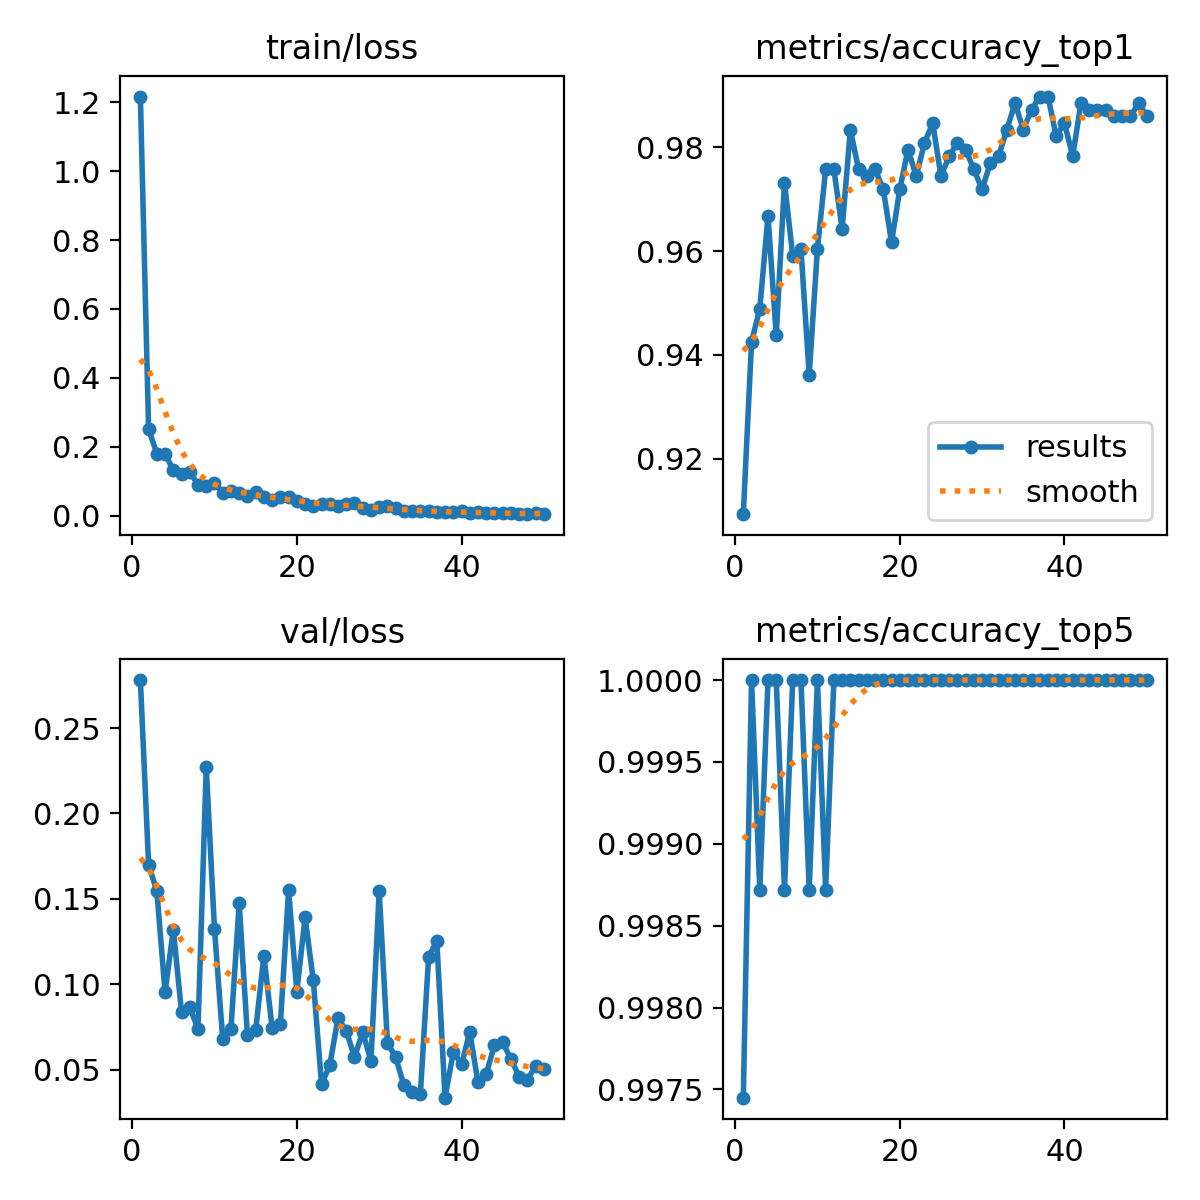

**confusion_matrix.png**

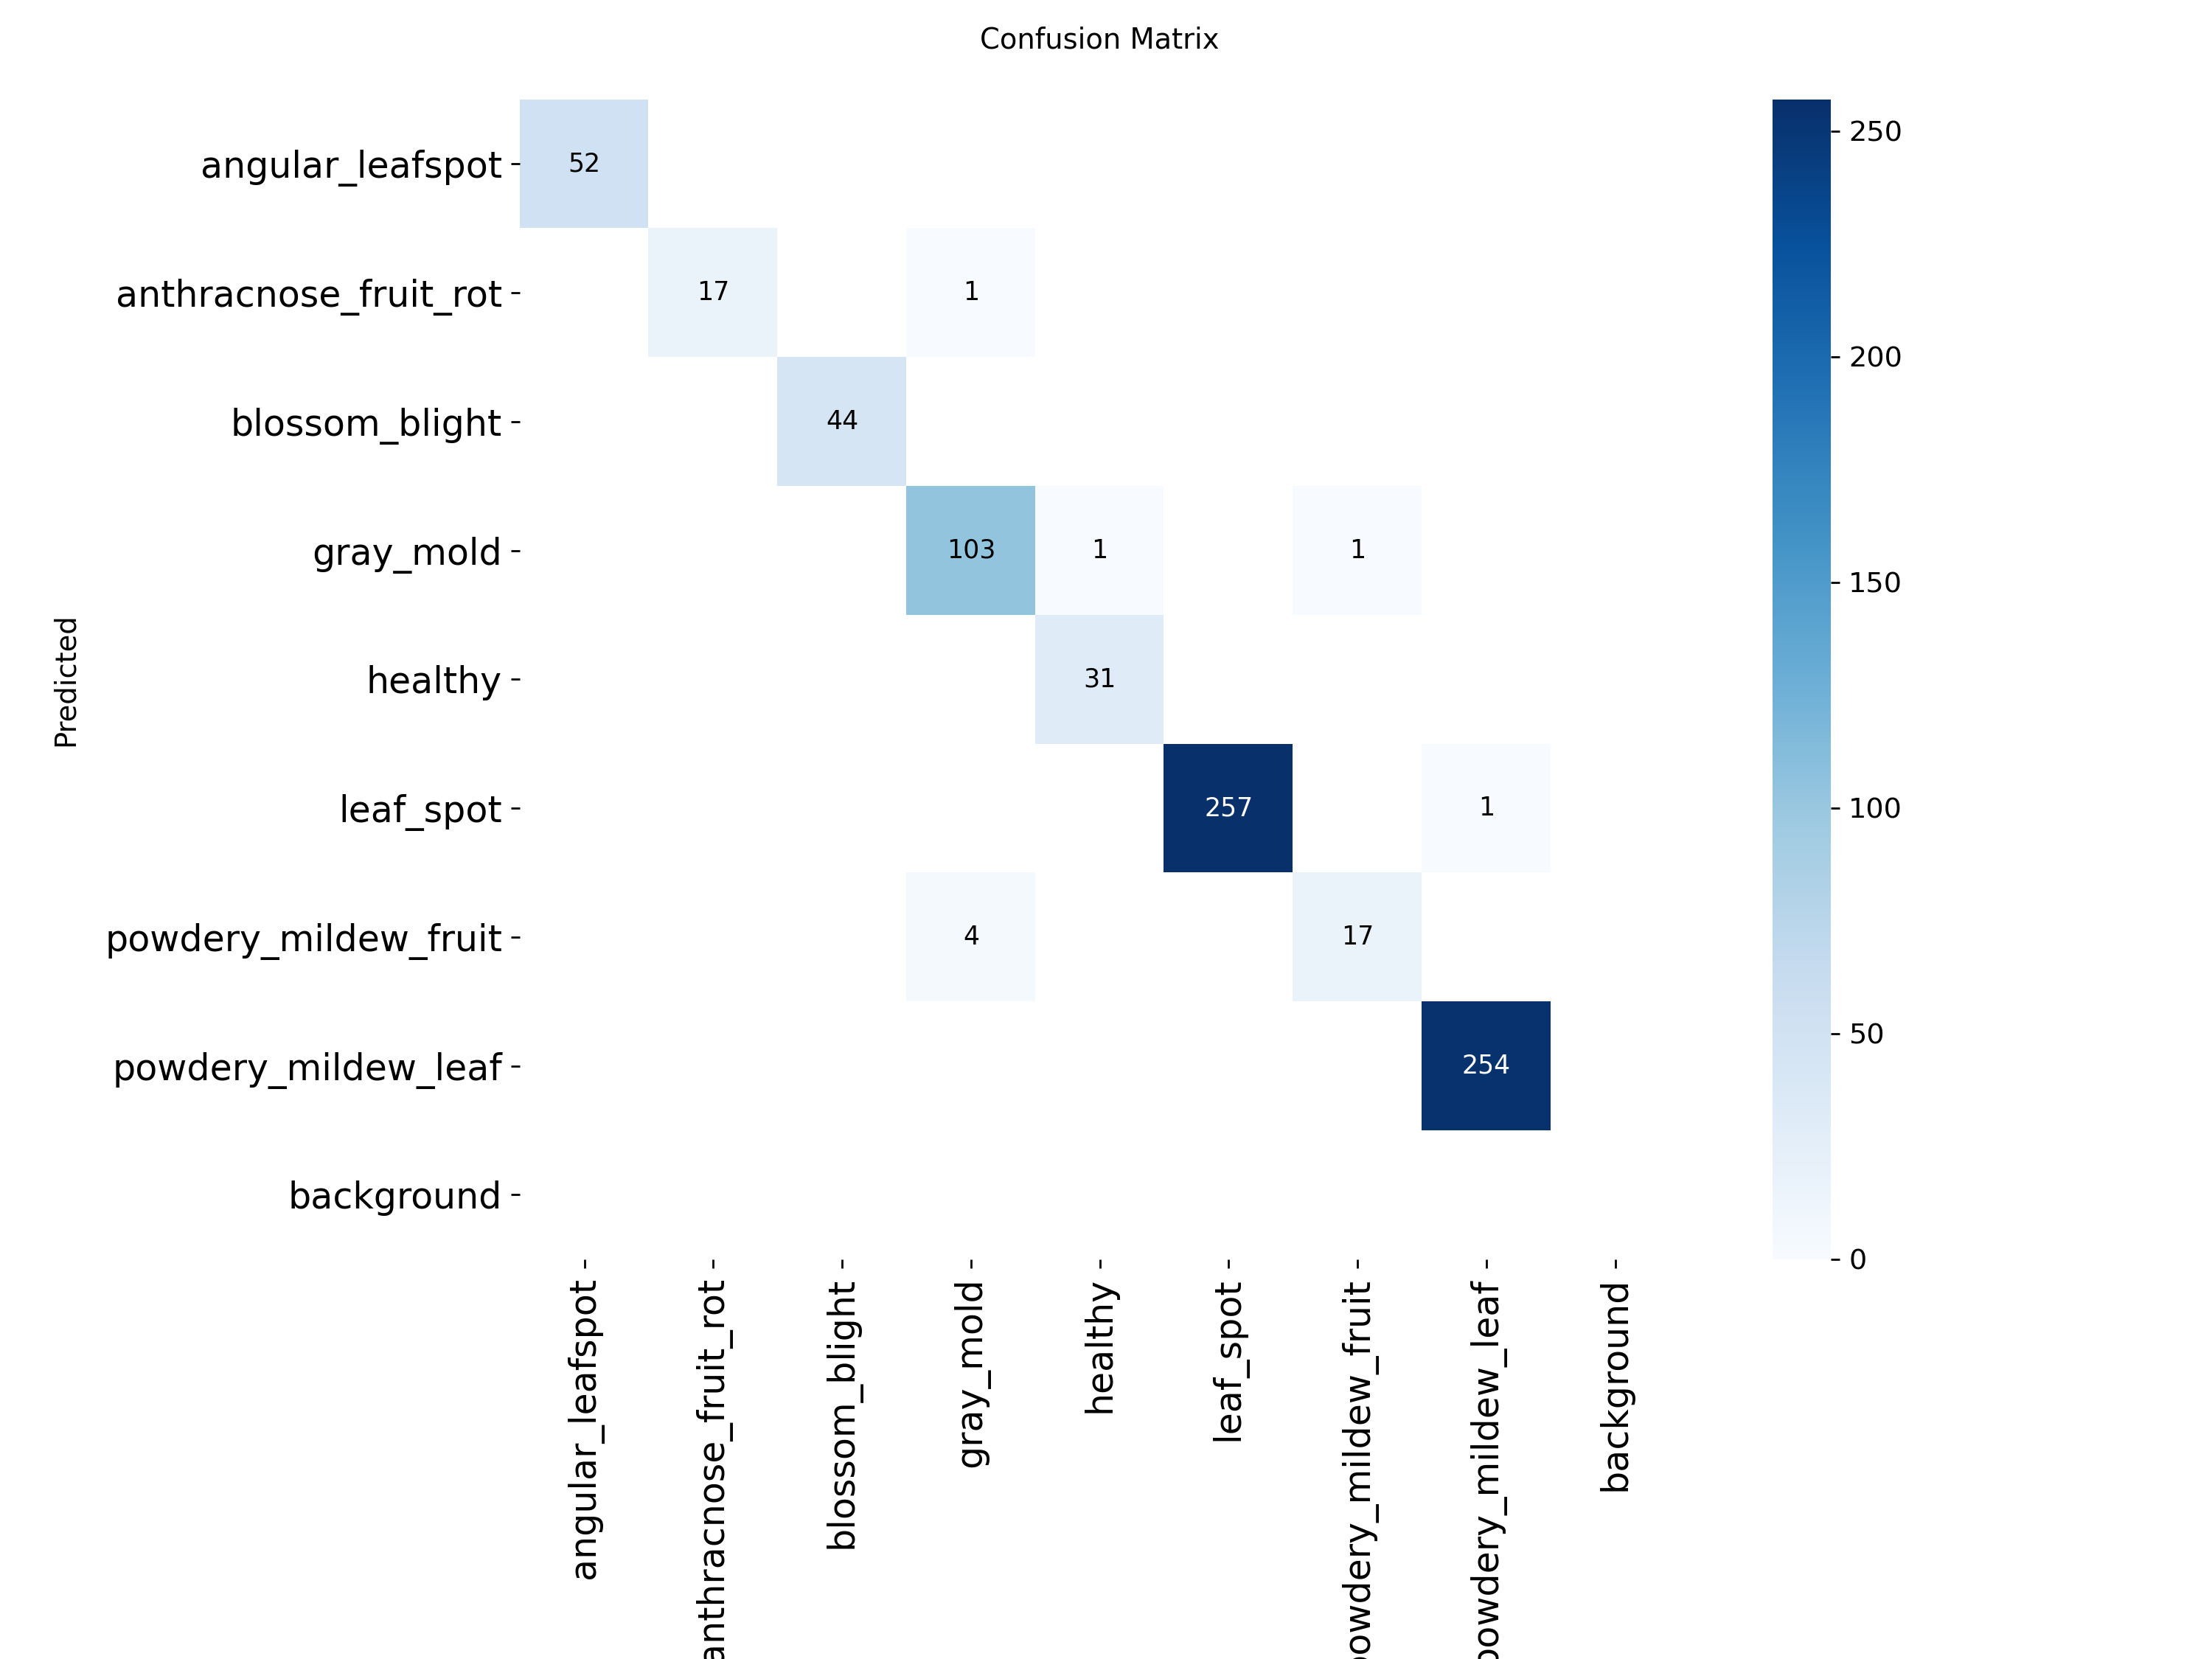

**confusion_matrix_normalized.png**

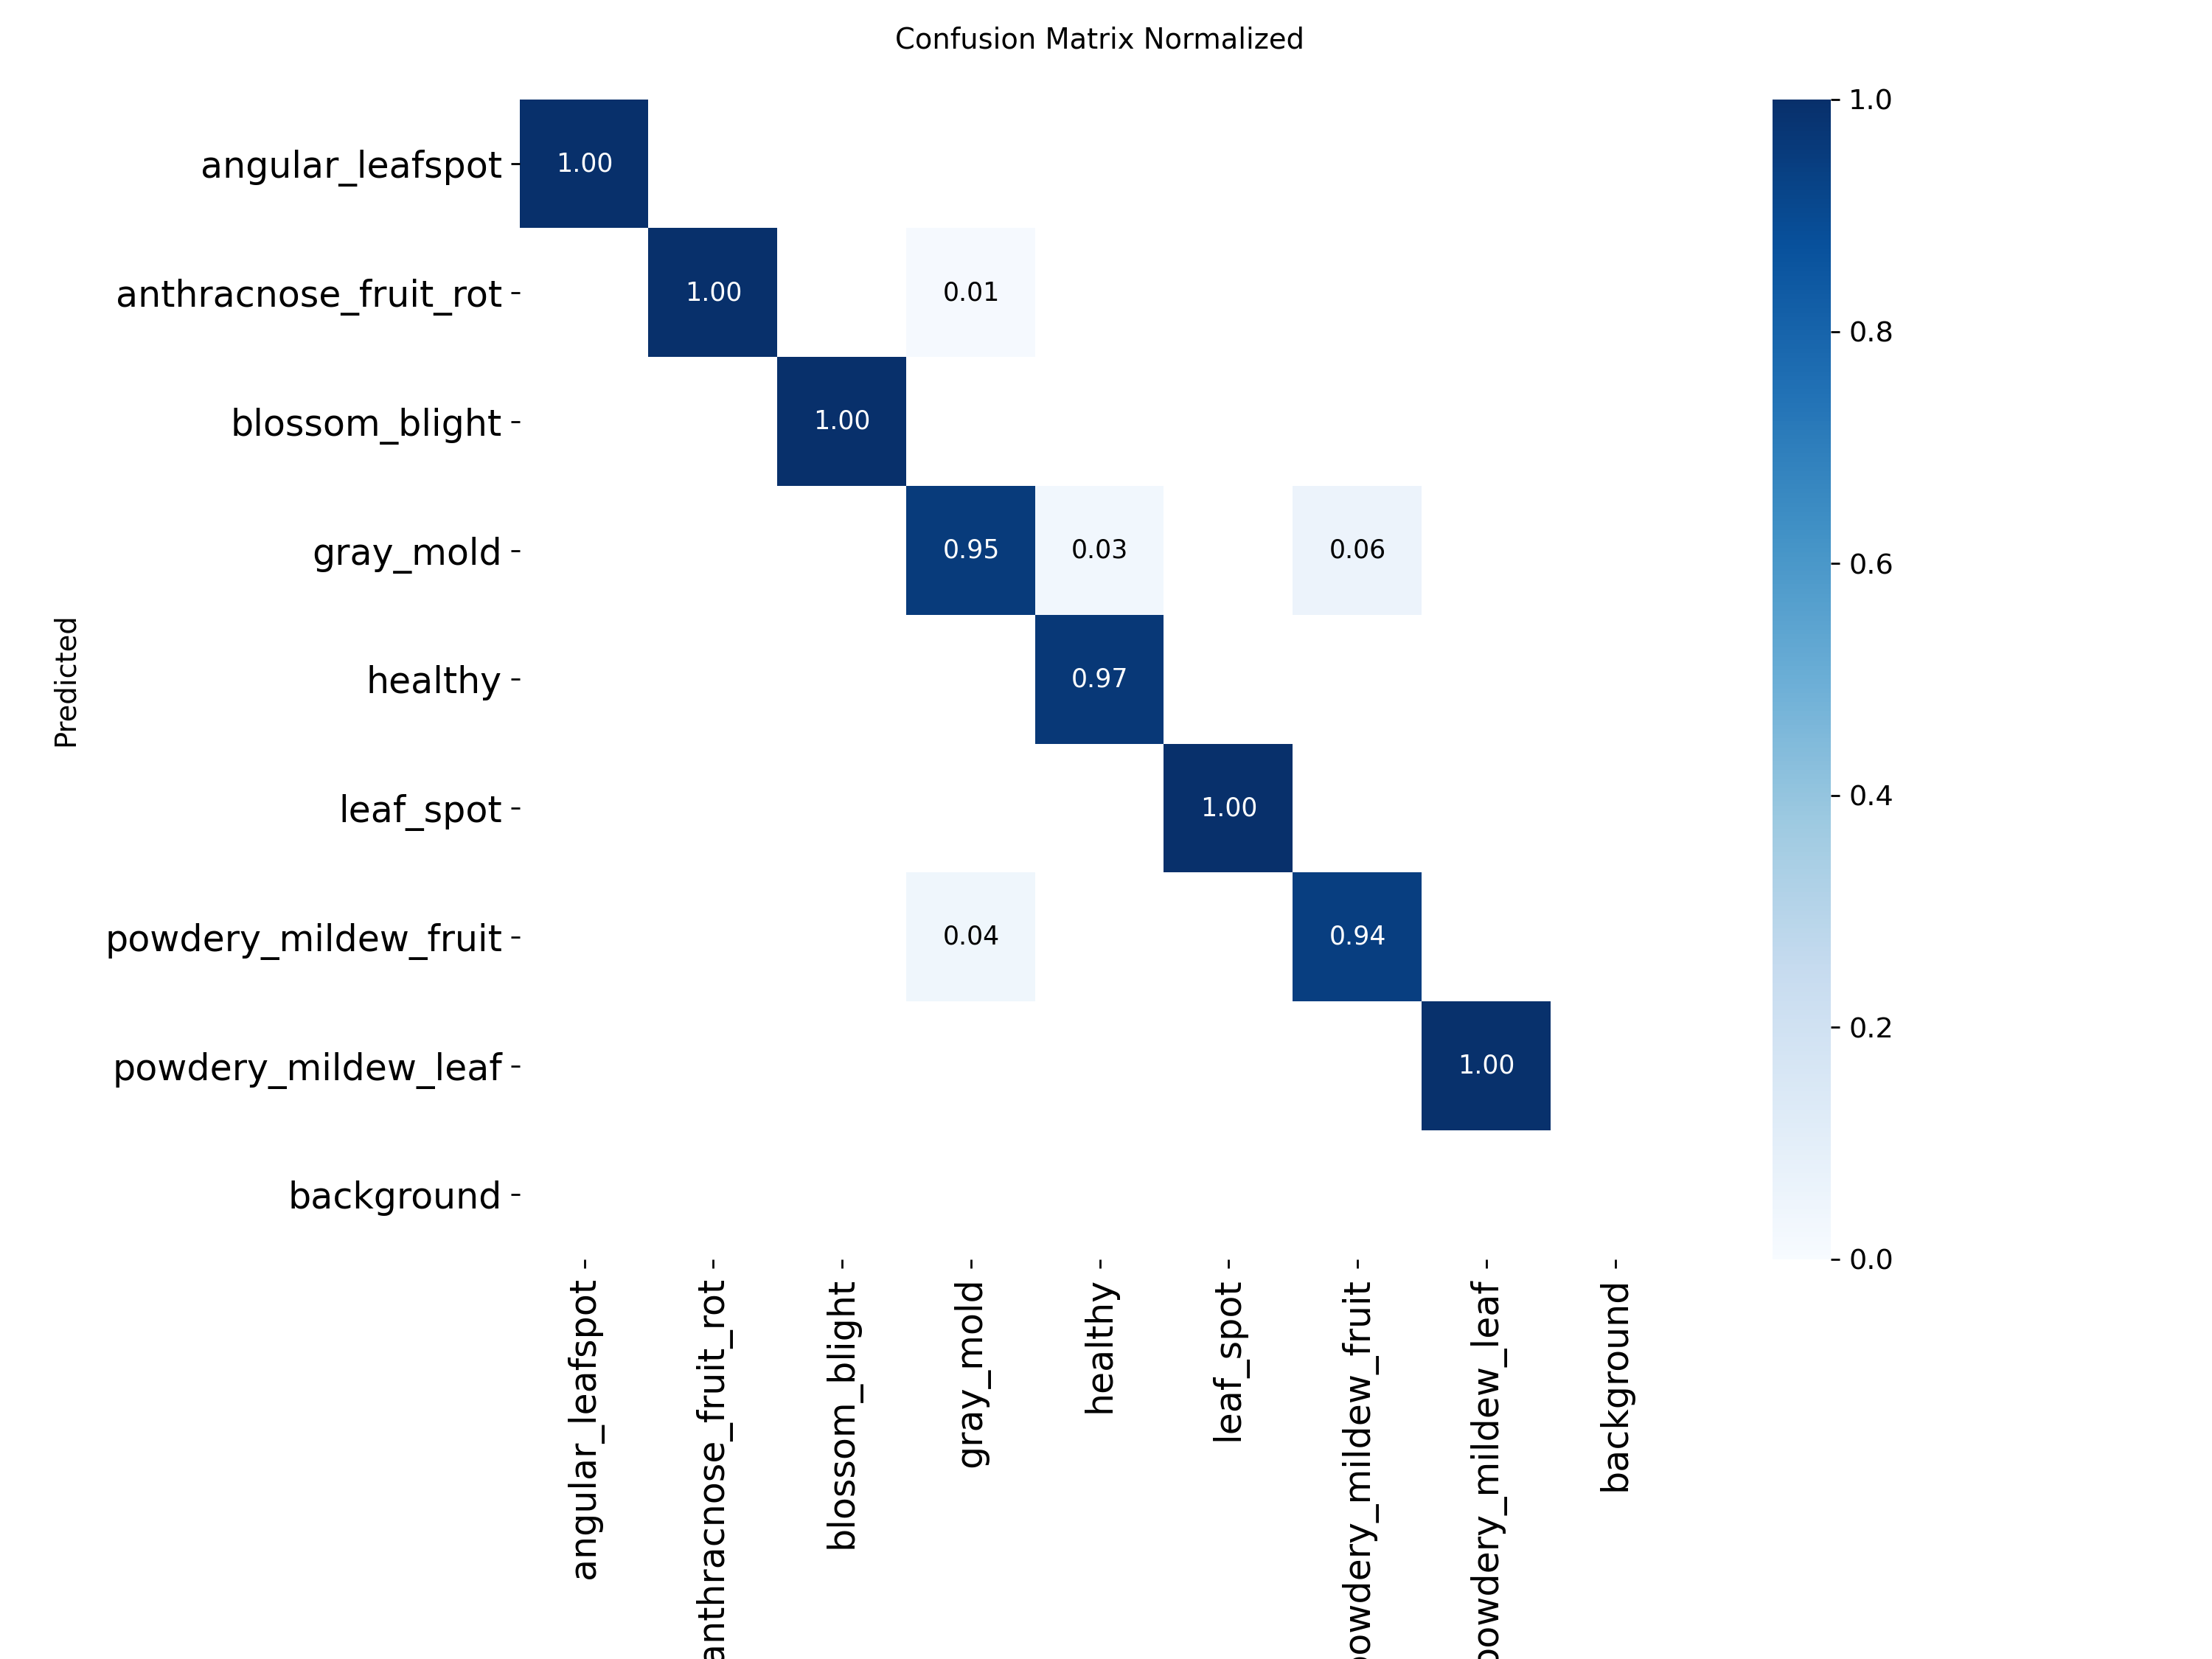

**val_batch0_pred.jpg**

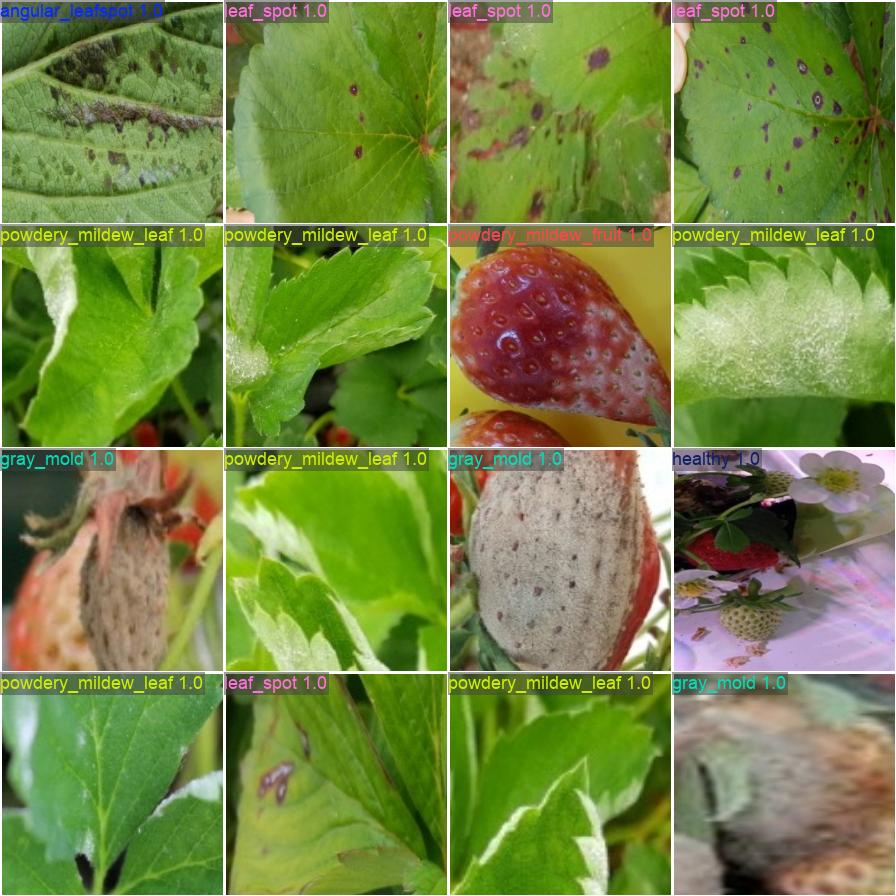

### disease_yolo26s_cls

In [18]:
import os
from IPython.display import Image, display, Markdown

RUN_NAMES = ['disease_yolo26n_cls', 'disease_yolo26s_cls']
PLOT_FILES = (
    'results.png',
    'confusion_matrix.png',
    'confusion_matrix_normalized.png',
    'val_batch0_pred.jpg',
)

for name in RUN_NAMES:
    run_dir = f'{PROJECT_DIR}/{name}'
    if not os.path.isdir(run_dir):
        continue
    display(Markdown(f'### {name}'))
    for fname in PLOT_FILES:
        path = os.path.join(run_dir, fname)
        if os.path.exists(path):
            display(Markdown(f'**{fname}**'))
            display(Image(path))

## 11. Download weights

In [19]:
import os
from google.colab import files

for name in ('disease_yolo26n_cls', 'disease_yolo26s_cls'):
    best = f'{PROJECT_DIR}/{name}/weights/best.pt'
    if os.path.exists(best):
        print(f'downloading {name}/best.pt')
        files.download(best)
    else:
        print(f'(skip) {name}/best.pt does not exist')

downloading disease_yolo26n_cls/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(skip) disease_yolo26s_cls/best.pt does not exist


## Next steps (off-Colab)

1. Mac side: `mkdir -p models/disease && cp ~/Downloads/best.pt models/disease/yolo26n_cls.pt` (and `yolo26s_cls.pt` if you ran the ablation).
2. Mac side: `python scripts/export_cls_ncnn.py --weights models/disease/yolo26n_cls.pt` to produce `models/disease/yolo26n_cls_ncnn_model/`.
3. Mac side: publish weights as a GitHub Release (`v0.3.0-disease`) so the Pi can curl them down — same pattern as Phase 2.
4. Pi side: pull the NCNN bundle and run `scripts/bench_cls_ncnn.py` per `docs/cursor-phase3-cls-bench.md`.
5. Phase 4 territory: integrate detector + classifier in `src/run_inference.py`, run the evaluator against ground truth.